# Telugu Books Text Chunking and Preprocessing

This notebook processes Telugu literature text files from the `book_data` folder and creates semantic chunks of up to 150 words per chunk, storing them in a CSV file.

## Step 1: Import Required Libraries

In [1]:
import os
import glob
import csv
import re
import spacy
from pathlib import Path
import pandas as pd
from tqdm import tqdm

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load spaCy Model for Telugu

We'll use spaCy's multilingual model or a blank Telugu model for text processing.

In [2]:
# Try to load a multilingual or Telugu model
# If no Telugu model is available, we'll create a blank one with sentence segmenter
try:
    nlp = spacy.load("xx_sent_ud_sm")  # Multilingual sentence segmenter
    print("Loaded multilingual spaCy model: xx_sent_ud_sm")
except:
    try:
        nlp = spacy.blank("te")  # Blank Telugu model
        nlp.add_pipe("sentencizer")  # Add sentence boundary detection
        print("Created blank Telugu spaCy model with sentencizer")
    except:
        # Fallback to English model which works reasonably well for sentence detection
        nlp = spacy.blank("en")
        nlp.add_pipe("sentencizer")
        print("Using blank English model with sentencizer as fallback")

Created blank Telugu spaCy model with sentencizer


## Step 3: Define Helper Functions

Functions for:
- Reading UTF-8 files
- Counting words in Telugu text
- Creating semantic chunks based on paragraphs

In [3]:
def read_utf8_file(file_path):
    """
    Read a UTF-8 encoded file and return its content.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
        return content
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return ""


def count_words(text):
    """
    Count words in Telugu text.
    Telugu words are separated by spaces and punctuation.
    """
    # Remove extra whitespace and split by spaces
    words = text.split()
    # Filter out empty strings
    words = [w for w in words if w.strip()]
    return len(words)


def split_into_paragraphs(text):
    """
    Split text into paragraphs based on double line breaks or significant whitespace.
    """
    # Split by double newlines or more
    paragraphs = re.split(r'\n\s*\n', text)
    # Clean up paragraphs
    paragraphs = [p.strip() for p in paragraphs if p.strip()]
    return paragraphs


def create_semantic_chunks(text, max_words=150):
    """
    Create semantic chunks from text based on paragraphs.
    Each chunk will have up to max_words words.
    
    Strategy:
    1. Split text into paragraphs
    2. Process paragraphs using spaCy for sentence detection
    3. Combine sentences/paragraphs into chunks of up to max_words
    """
    chunks = []
    
    # First split into paragraphs
    paragraphs = split_into_paragraphs(text)
    
    current_chunk = ""
    current_word_count = 0
    
    for paragraph in paragraphs:
        paragraph = paragraph.strip()
        if not paragraph:
            continue
            
        # Process paragraph with spaCy to get sentences
        doc = nlp(paragraph)
        sentences = [sent.text.strip() for sent in doc.sents]
        
        for sentence in sentences:
            sentence_word_count = count_words(sentence)
            
            # If adding this sentence exceeds max_words and we already have content
            if current_word_count + sentence_word_count > max_words and current_chunk:
                # Save current chunk and start a new one
                chunks.append(current_chunk.strip())
                current_chunk = sentence
                current_word_count = sentence_word_count
            else:
                # Add sentence to current chunk
                if current_chunk:
                    current_chunk += " " + sentence
                else:
                    current_chunk = sentence
                current_word_count += sentence_word_count
    
    # Add the last chunk if it exists
    if current_chunk.strip():
        chunks.append(current_chunk.strip())
    
    return chunks


print("Helper functions defined successfully!")

Helper functions defined successfully!


## Step 4: Get All UTF-8 Files from book_data Folder

In [6]:
# Define the path to the book_data folder
book_data_folder = Path("ai_novel")

# Get all .utf8 files
utf8_files = sorted(list(book_data_folder.glob("*.utf8")))

print(f"Found {len(utf8_files)} UTF-8 files in the book_data folder")
print(f"\nFirst 10 files:")
for file in utf8_files[:10]:
    print(f"  - {file.name}")

Found 20 UTF-8 files in the book_data folder

First 10 files:
  - is16.utf8
  - is17.utf8
  - is18.utf8
  - is19.utf8
  - is20.utf8
  - ls1.utf8
  - ls10.utf8
  - ls11.utf8
  - ls12.utf8
  - ls13.utf8


## Step 5: Process All Files and Create Chunks

This will:
1. Read each UTF-8 file
2. Create semantic chunks (up to 150 words each)
3. Track metadata (file name, chunk number)

In [7]:
# Store all chunks with metadata
all_chunks_data = []

print("Processing files and creating chunks...\n")

# Process each file with progress bar
for file_path in tqdm(utf8_files, desc="Processing files"):
    # Read file content
    content = read_utf8_file(file_path)
    
    if not content.strip():
        print(f"Skipping empty file: {file_path.name}")
        continue
    
    # Create semantic chunks
    chunks = create_semantic_chunks(content, max_words=200)
    
    # Store each chunk with metadata
    for idx, chunk in enumerate(chunks, start=1):
        word_count = count_words(chunk)
        all_chunks_data.append({
            'file_name': file_path.name,
            'chunk_number': idx,
            'word_count': word_count,
            'chunk_text': chunk
        })

print(f"\nProcessing complete!")
print(f"Total chunks created: {len(all_chunks_data)}")
print(f"Total files processed: {len(utf8_files)}")

Processing files and creating chunks...



Processing files:   0%|          | 0/20 [00:00<?, ?it/s]

Processing files: 100%|██████████| 20/20 [00:00<00:00, 26.41it/s]


Processing complete!
Total chunks created: 110
Total files processed: 20


## Step 6: Display Sample Chunks

Let's view a few sample chunks to verify the output.

In [8]:
# Create DataFrame for better visualization
df_chunks = pd.DataFrame(all_chunks_data)

print("Sample chunks from the dataset:\n")
print("="*80)

# Display first 3 chunks
for i in range(min(3, len(df_chunks))):
    row = df_chunks.iloc[i]
    print(f"\nChunk {i+1}:")
    print(f"File: {row['file_name']}")
    print(f"Chunk Number: {row['chunk_number']}")
    print(f"Word Count: {row['word_count']}")
    print(f"Text Preview (first 200 chars):\n{row['chunk_text'][:200]}...")
    print("="*80)

# Display statistics
print("\n\nDataset Statistics:")
print(f"Total chunks: {len(df_chunks)}")
print(f"Average words per chunk: {df_chunks['word_count'].mean():.2f}")
print(f"Min words per chunk: {df_chunks['word_count'].min()}")
print(f"Max words per chunk: {df_chunks['word_count'].max()}")
print(f"Unique files: {df_chunks['file_name'].nunique()}")

# Display first few rows of dataframe
print("\n\nDataFrame preview:")
df_chunks.head()

Sample chunks from the dataset:


Chunk 1:
File: is16.utf8
Chunk Number: 1
Word Count: 193
Text Preview (first 200 chars):
మీరు మొత్తం కథ, **"నేను బతకాలి"** ను ఒకే టెక్స్ట్ ఫార్మాట్‌లో కావాలని అడుగుతున్నారు. మీకు సహాయం చేయడానికి, కథా వచనాన్ని (text) మొత్తం కింద ఇస్తున్నాను. నేను మీకు నేరుగా **.txt ఫైల్‌ను సృష్టించి పంపలేన...

Chunk 2:
File: is16.utf8
Chunk Number: 2
Word Count: 199
Text Preview (first 200 chars):
రామారావు మర్యాదకు, మాటలకు కరిగిపోయిన ఆదినారాయణ, యశోద వ్యతిరేకించినా వినకుండా, రామారావుతో **డెవలప్‌మెంట్ ఒప్పందం** చేసుకున్నాడు. "యశోదా, మమత (మానవత్వం) ముఖ్యం. రామారావు అంత మర్యాదగా మాట్లాడుతున్నాడు, మ...

Chunk 3:
File: is16.utf8
Chunk Number: 3
Word Count: 193
Text Preview (first 200 chars):
అతని జీవితంలో నిజమైన చీకటి మొదలైంది. ## **అధ్యాయం 5: మమత యొక్క పోరాటం** ఆదినారాయణ మనసులో బాధ, పశ్చాత్తాపం ఉన్నా, కూతురు **సౌమ్య** మాత్రం తన తండ్రిని నమ్మింది. " నాన్న, మీరు మోసం చేయలేదు, మోసపోయారు. మీ...


Dataset Statistics:
Total chunks: 110
Average words per chunk: 178.55
Min words per

,file_name,chunk_number,word_count,chunk_text
0,is16.utf8,1,193,"మీరు మొత్తం కథ, **""నేను బతకాలి""** ను ఒకే టెక్స..."
1,is16.utf8,2,199,"రామారావు మర్యాదకు, మాటలకు కరిగిపోయిన ఆదినారాయణ..."
2,is16.utf8,3,193,అతని జీవితంలో నిజమైన చీకటి మొదలైంది. ## **అధ్య...
3,is16.utf8,4,173,"రామారావు ఆదినారాయణకు నష్టపరిహారంతో పాటు, ఆ ఇంట..."
4,is17.utf8,1,193,"మీరు మొత్తం కథ, **""మాటకాని మౌనం""** ను ఒకే టెక్..."


## Step 7: Save Chunks to CSV File

Save all chunks to a CSV file with proper encoding for Telugu text.

In [9]:
# Define output CSV filename
output_csv = "telugu_ai_chunks.csv"

# Save to CSV with UTF-8 encoding
df_chunks.to_csv(output_csv, index=False, encoding='utf-8-sig')

print(f" Successfully saved {len(df_chunks)} chunks to '{output_csv}'")
print(f" CSV file size: {os.path.getsize(output_csv) / (1024*1024):.2f} MB")
print(f"\nColumns in CSV: {list(df_chunks.columns)}")

 Successfully saved 110 chunks to 'telugu_ai_chunks.csv'
 CSV file size: 0.37 MB

Columns in CSV: ['file_name', 'chunk_number', 'word_count', 'chunk_text']


## Step 8: Verify CSV Output (Optional)

Read back a few rows from the CSV to verify it was saved correctly.

In [10]:
# Read the CSV file back
df_verify = pd.read_csv(output_csv, encoding='utf-8-sig')

print(f"CSV file loaded successfully!")
print(f"Shape: {df_verify.shape}")
print(f"\nFirst 5 rows:")
df_verify.head()

CSV file loaded successfully!
Shape: (110, 4)

First 5 rows:


,file_name,chunk_number,word_count,chunk_text
0,is16.utf8,1,193,"మీరు మొత్తం కథ, **""నేను బతకాలి""** ను ఒకే టెక్స..."
1,is16.utf8,2,199,"రామారావు మర్యాదకు, మాటలకు కరిగిపోయిన ఆదినారాయణ..."
2,is16.utf8,3,193,అతని జీవితంలో నిజమైన చీకటి మొదలైంది. ## **అధ్య...
3,is16.utf8,4,173,"రామారావు ఆదినారాయణకు నష్టపరిహారంతో పాటు, ఆ ఇంట..."
4,is17.utf8,1,193,"మీరు మొత్తం కథ, **""మాటకాని మౌనం""** ను ఒకే టెక్..."


## Additional Analysis (Optional)

Visualize the distribution of chunk sizes and files.

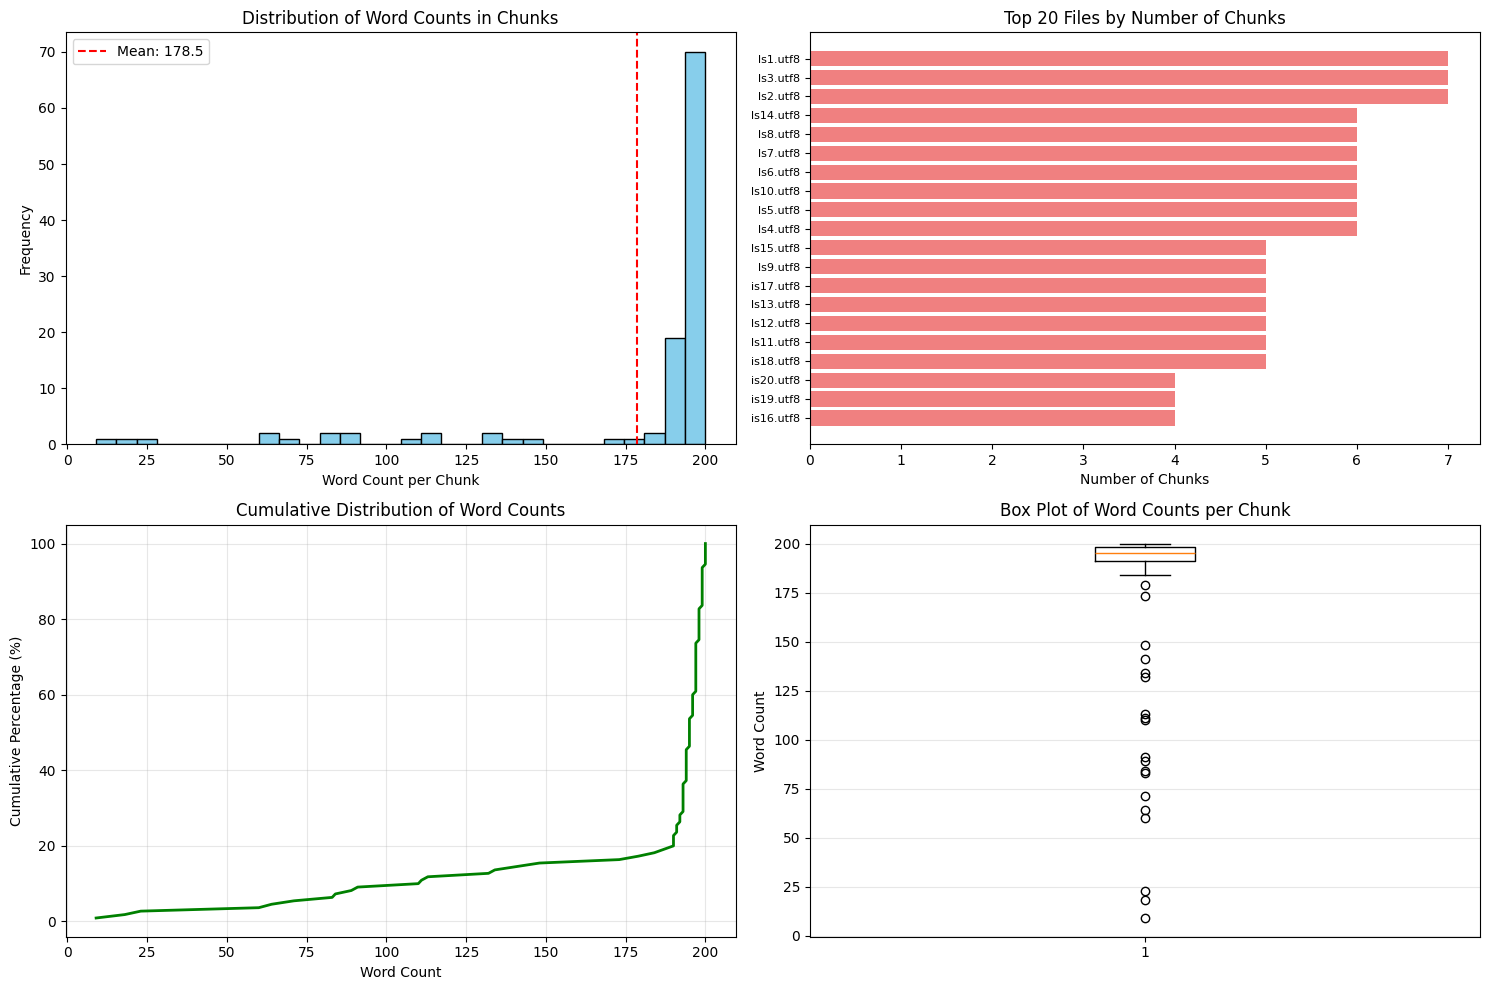


✓ Visualization saved as 'chunk_analysis.png'


In [11]:
import matplotlib.pyplot as plt

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution of word counts
axes[0, 0].hist(df_chunks['word_count'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Word Count per Chunk')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Word Counts in Chunks')
axes[0, 0].axvline(df_chunks['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df_chunks["word_count"].mean():.1f}')
axes[0, 0].legend()

# 2. Number of chunks per file (top 20 files)
chunks_per_file = df_chunks['file_name'].value_counts().head(20)
axes[0, 1].barh(range(len(chunks_per_file)), chunks_per_file.values, color='lightcoral')
axes[0, 1].set_yticks(range(len(chunks_per_file)))
axes[0, 1].set_yticklabels(chunks_per_file.index, fontsize=8)
axes[0, 1].set_xlabel('Number of Chunks')
axes[0, 1].set_title('Top 20 Files by Number of Chunks')
axes[0, 1].invert_yaxis()

# 3. Cumulative word count distribution
sorted_counts = sorted(df_chunks['word_count'])
cumulative = [i/len(sorted_counts)*100 for i in range(1, len(sorted_counts)+1)]
axes[1, 0].plot(sorted_counts, cumulative, color='green', linewidth=2)
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Cumulative Percentage (%)')
axes[1, 0].set_title('Cumulative Distribution of Word Counts')
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot of word counts
axes[1, 1].boxplot(df_chunks['word_count'], vert=True)
axes[1, 1].set_ylabel('Word Count')
axes[1, 1].set_title('Box Plot of Word Counts per Chunk')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('chunk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'chunk_analysis.png'")

## Summary

### What this notebook does:
1. **Reads** all `.utf8` files from the `book_data` folder containing Telugu literature
2. **Processes** the text using spaCy for semantic understanding
3. **Creates chunks** based on paragraphs and sentences, with each chunk containing up to 150 words
4. **Maintains semantic meaning** by not breaking in the middle of sentences
5. **Saves** all chunks to a CSV file with metadata (filename, chunk number, word count)

### Output:
- **CSV file**: `telugu_books_chunks.csv` with columns:
  - `file_name`: Source file name
  - `chunk_number`: Sequential chunk number within that file
  - `word_count`: Number of words in the chunk
  - `chunk_text`: The actual text content

### Prerequisites:
Before running this notebook, ensure you have installed:
```bash
pip install spacy pandas tqdm matplotlib
```

For Telugu/multilingual support (optional):
```bash
python -m spacy download xx_sent_ud_sm
```

### Next Steps:
You can use the generated CSV file for:
- Training language models
- Text classification
- Sentiment analysis
- Information retrieval
- Any other NLP task on Telugu literature

In [12]:
import pandas as pd
import re
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
from tqdm import tqdm

tqdm.pandas()

factory = IndicNormalizerFactory()
normalizer = factory.get_normalizer("te")

def clean_telugu_text(text):
    """
    Removes non-Telugu characters, normalizes the text, and cleans up whitespace.
    """
    if not isinstance(text, str):
        return ""
    cleaned_text = re.sub(r'[^\u0C00-\u0C7F\s]', '', text)
    normalized_text = normalizer.normalize(cleaned_text)
    normalized_text = re.sub(r'\s+', ' ', normalized_text).strip()
    return normalized_text

def count_words_telugu(text):
    """
    Counts words in a string by splitting on whitespace.
    """
    if not isinstance(text, str):
        return 0
    return len(text.split())

csv_file = "telugu_ai_chunks.csv"
print(f"Loading data from '{csv_file}'...")
try:
    df = pd.read_csv(csv_file, encoding='utf-8-sig')
    print(f"Successfully loaded {len(df)} rows.")
    
    print("\nCleaning 'chunk_text' column to remove non-Telugu content...")
    df['chunk_text'] = df['chunk_text'].progress_apply(clean_telugu_text)
    print("Text cleaning complete.")

    print("\nRecalculating word counts...")
    df['word_count'] = df['chunk_text'].progress_apply(count_words_telugu)
    print("Word count recalculation complete.")

    df.to_csv(csv_file, index=False, encoding='utf-8-sig')
    print(f"\nSuccessfully cleaned and saved the data back to '{csv_file}'.")
    
    print("\nSample of cleaned data:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: The file '{csv_file}' was not found. Please run the preceding cells to generate it.")
except Exception as e:
    print(f"An error occurred: {e}")


Loading data from 'telugu_ai_chunks.csv'...
Successfully loaded 110 rows.

Cleaning 'chunk_text' column to remove non-Telugu content...


  0%|          | 0/110 [00:00<?, ?it/s]

100%|██████████| 110/110 [00:00<00:00, 2115.31it/s]



Text cleaning complete.

Recalculating word counts...


100%|██████████| 110/110 [00:00<00:00, 15706.86it/s]

Word count recalculation complete.

Successfully cleaned and saved the data back to 'telugu_ai_chunks.csv'.

Sample of cleaned data:
   file_name  chunk_number  word_count  \
0  is16.utf8             1         180   
1  is16.utf8             2         195   
2  is16.utf8             3         184   
3  is16.utf8             4         167   
4  is17.utf8             1         181   

                                          chunk_text  
0  మీరు మొత్తం కథ నేను బతకాలి ను ఒకే టెక్స్ట్ ఫార...  
1  రామారావు మర్యాదకు మాటలకు కరిగిపోయిన ఆదినారాయణ ...  
2  అతని జీవితంలో నిజమైన చీకటి మొదలైంది అధ్యాయం మమ...  
3  రామారావు ఆదినారాయణకు నష్టపరిహారంతో పాటు ఆ ఇంట్...  
4  మీరు మొత్తం కథ మాటకాని మౌనం ను ఒకే టెక్స్ట్ ఫా...  


In [14]:
csv_file = "telugu_ai_chunks.csv"
d=pd.read_csv(csv_file, encoding='utf-8-sig')
d['word_count'].mean()

171.01818181818183